In [1]:
import csv
import hashlib
import json
import sys
from collections import defaultdict
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from tqdm.auto import tqdm

/home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path("../data")

In [ ]:
def load_dataset(path: str | Path) -> dict[int, list[str]]:
    """
    Args:
        path: Path to the dataset root.

    Returns:
        dict: Spacegroup number to list of structures in that spacegroup.
    """
    if not isinstance(path, Path):
        path = Path(path)

    if path.is_dir():
        json_files = sorted(path.rglob("*.json"))
        csv_files = sorted(path.rglob("*.csv"))
        files = json_files + csv_files
    elif path.is_file():
        files = [path]
    else:
        raise ValueError(f"Path {path} is neither a file nor a directory.")

    print("Loading dataset from: ", files)

    dataset = {i: [] for i in range(1, 231)}

    for datafile in tqdm(files):
        dataset_name = datafile.parents[1].name
        if dataset_name in ["aflow", "mp"]:
            data = json.loads(datafile.read_text())
            idx = int(datafile.stem.split("_")[-1])
            dataset[idx] += [entry["structure"] for entry in data]

        elif dataset_name == "gnome":
            data = pd.read_csv(datafile)
            file_root = datafile.parent

            for idx, group in tqdm(
                data.groupby("Space Group Number"), desc=f"Loading {datafile.name}"
            ):
                filtered_data = [file_root / "by_id" / f"{x}.CIF" for x in group["MaterialId"]]
                structures = [
                    Structure.from_str(data.read_text(), fmt="cif").to(fmt="poscar")
                    for data in tqdm(filtered_data, desc="Files in chunk", leave=False)
                ]
                dataset[idx].extend(structures) #type: ignore
        elif dataset_name == "csg":
            data = pd.read_csv(datafile)
            for row in tqdm(data.itertuples(), desc="Loading CSG dataset", total=len(data)):
                idx = int(row[1])
                structure_str = Structure.from_str(row[2], fmt="poscar")
                dataset[idx].append(structure_str)
        else:
            raise ValueError(f"Unknown dataset {dataset_name}")

    return dataset

In [4]:
def load_labels(path: str | Path) -> dict[int, int]:
    if not isinstance(path, Path):
        path = Path(path)

    dataset_config = {
        "aflow": {"type": "json", "spacegroup_key": "spacegroup"},
        "material_project": {"type": "json", "spacegroup_key": "spacegroup"},
        "gnome": {"type": "csv", "spacegroup_key": "Space Group Number"},
        "csg": {"type": "csv", "spacegroup_key": "SpaceGroupNumber"},
    }

    files = sorted(path.rglob("*.json")) + sorted(path.rglob("*.csv"))

    dataset = defaultdict(int)
    for datafile in files:
        dataset_name = datafile.parents[1].name
        if dataset_name not in dataset_config:
            raise ValueError(f"Unknown dataset {dataset_name}")

        config = dataset_config[dataset_name]
        if config["type"] == "json":
            data = json.loads(datafile.read_text())
            idx = int(datafile.stem.split("_")[-1])
            n_elem = len([entry[config["spacegroup_key"]] for entry in data])
            if n_elem:
                dataset[idx] += n_elem
        elif config["type"] == "csv":
            data = pd.read_csv(datafile, usecols=[config["spacegroup_key"]])
            for idx, group in data.groupby(config["spacegroup_key"]):
                dataset[idx] += len(group[config["spacegroup_key"]].tolist())  # type: ignore

    return dataset

In [5]:
all_sg = list(range(1, 231))
labels = list(load_labels(ROOT).keys())
pprint(f"Missing labels: {sorted(set(all_sg) - set(labels))}")
pprint(f"Prensent labels: {sorted(set(all_sg) & set(labels))}")

'Missing labels: [168, 207]'
('Prensent labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, '
 '18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, '
 '37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, '
 '56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, '
 '75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, '
 '94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, '
 '110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, '
 '125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, '
 '140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, '
 '155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 169, 170, '
 '171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, '
 '186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, '
 '201, 202, 203, 2

In [6]:
dataset = load_dataset(ROOT / "csg" / "raw" / "CSG_tiny.csv")

Loading dataset from:  [PosixPath('../data/csg/raw/CSG_tiny.csv')]


100%|██████████| 1/1 [00:51<00:00, 51.74s/it]


In [35]:
total_atoms = 0
max_atoms = 0
all_length = []

for sg, structures in dataset.items():
    for struct in structures:
        total_atoms += len(struct)
        max_atoms = max(max_atoms, len(struct))
        all_length.append(len(struct))

print(f"Total structures: {sum(len(v) for v in dataset.values()):,}")
print(f"Total atoms: {total_atoms:,}")
print()
print(f"Max atoms in a structure: {max_atoms}")
print(f"Structure size (median): {np.quantile(all_length, 0.5)}")
print(f"Structure size (90 quantile): {np.quantile(all_length, 0.90)}")
print(f"Structure size (95 quantile): {np.quantile(all_length, 0.95)}")
print(f"Structure size (96 quantile): {np.quantile(all_length, 0.96)}")
print(f"Structure size (97 quantile): {np.quantile(all_length, 0.97)}")
print(f"Structure size (98 quantile): {np.quantile(all_length, 0.98)}")
print(f"Structure size (99 quantile): {np.quantile(all_length, 0.99)}")

Total structures: 204,482
Total atoms: 4,419,342

Max atoms in a structure: 392
Structure size (median): 17.0
Structure size (90 quantile): 36.0
Structure size (95 quantile): 56.0
Structure size (96 quantile): 64.0
Structure size (97 quantile): 76.0
Structure size (98 quantile): 88.0
Structure size (99 quantile): 111.0


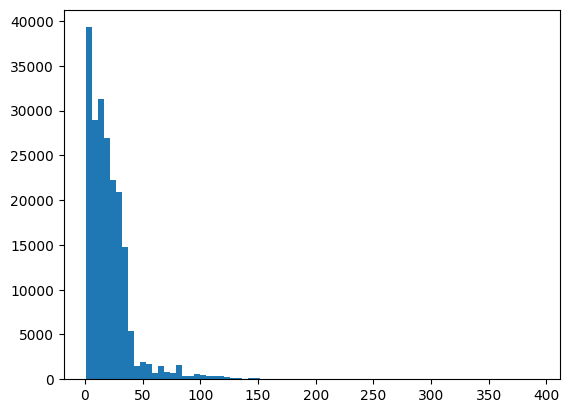

In [34]:
_ = plt.hist(all_length, density=False, bins=75, log=False)

In [8]:
def filter_dataset(dataset: dict[int, list[str]]) -> dict[int, list[str]]:
    """
    Filter the dataset to only include unique compositions for each spacegroup.

    Args:
        dataset: Spacegroup number to list of structures in that spacegroup.

    Returns

        dict: Spacegroup number to list of structures in that spacegroup.
    """
    filtered_dataset = {}
    for i in tqdm(range(1, 231), desc="Filtering dataset chunks"):
        filtered_dataset[i] = []
        seen_formulas = set()
        for struct_str in dataset[i]:
            struct = Structure.from_str(struct_str, fmt="poscar")

            formula = struct.composition.formula
            if formula not in seen_formulas:
                seen_formulas.add(formula)
                filtered_dataset[i].append(struct_str)
    return filtered_dataset

In [9]:
# dataset = load_dataset(ROOT)
dataset_length = sum(len(v) for v in dataset.values())

In [10]:
filtered_dataset = filter_dataset(dataset)

Filtering dataset chunks:   0%|          | 0/230 [00:00<?, ?it/s]


AttributeError: 'Structure' object has no attribute 'rstrip'

In [ ]:
def sizeof_fmt(num, suffix="B"):
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

In [ ]:
filter_dataset_length = sum(len(v) for v in filtered_dataset.values())

print(f"Original dataset length: {dataset_length}")
print(f"Filtered dataset length: {filter_dataset_length}")
print(
    f"Dataset length reduction: {dataset_length - filter_dataset_length} "
    f"({(dataset_length - filter_dataset_length) / dataset_length * 100:.2f}%)",
    end="\n\n",
)

dataset_size = sum(sys.getsizeof(v) for v in dataset.values())
filtered_dataset_size = sum(sys.getsizeof(v) for v in filtered_dataset.values())

print(f"Memory usage of the original dataset: {sizeof_fmt(dataset_size)}")
print(f"Memory usage of the filtered dataset: {sizeof_fmt(filtered_dataset_size)}")
print(
    f"Memory reduction: {sizeof_fmt(dataset_size - filtered_dataset_size)} "
    f"({(dataset_size - filtered_dataset_size) / dataset_size * 100:.2f}%)"
)

Original dataset length: 0
Filtered dataset length: 0


ZeroDivisionError: division by zero

In [ ]:
for i in range(1, 231):
    if len(dataset[i]) != len(filtered_dataset[i]):
        print(f"Spacegroup {i}: {len(dataset[i])} -> {len(filtered_dataset[i])}")

In [ ]:
pbar = tqdm(total=filter_dataset_length, desc="Writing to CSV")
with open(ROOT / "CSG.csv", "w") as csv_file:
    writer = csv.writer(csv_file)
    for key, values in filtered_dataset.items():
        for val in values:
            writer.writerow([key, val])
            pbar.update(1)

In [ ]:
df = pd.read_csv(ROOT / "csg" / "raw" / "CSG.csv")

In [ ]:
df.rename(columns={"0": "SpaceGroupNumber", "1": "Structure"}, inplace=True)

In [ ]:
df.to_csv(ROOT / "csg" / "raw" / "CSG.csv", index=False)

In [ ]:
def md5(fname):
    hash_md5 = hashlib.md5(usedforsecurity=False)
    with open(fname, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()


print(f"MD5 hash of the dataset: {md5(ROOT / 'CSG.csv')}")

In [ ]:
sg_count = np.array([len(filtered_dataset.get(k, [])) for k in filtered_dataset.keys()])

In [ ]:
available_sg = sg_count[sg_count > 0]
masked_count = sg_count[sg_count > 100]
imbalance = np.max(masked_count) / np.min(masked_count)

print(f"Number of space groups: {len(available_sg)}")
print(f"Number of relevant space group: {len(masked_count)}")
print(f"Imbalance: {imbalance}")

In [ ]:
print(f"Unavailable space groups: {np.where(sg_count == 0)[0] + 1}")

In [ ]:
plt.bar(np.arange(1, 231), sg_count, log=True, width=1)

plt.xlabel("Space group")
plt.ylabel("Number of entries")
plt.xlim(1, 230)